# Neural Networks for Healthcare Readmission Prediction

### Binary Classification Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving healthcare_readmission_dataset.csv to healthcare_readmission_dataset.csv


In [3]:
import io
df = pd.read_csv(io.BytesIO(uploaded['healthcare_readmission_dataset.csv']))
df.head()

,patient_id,age,bmi,systolic_bp,diastolic_bp,heart_rate,glucose_level,num_previous_admissions,length_of_stay,chronic_condition,smoker,insurance_type,medication_count,followup_appointment,readmitted_30_days
0,PAT00001,69,31.9,127.0,76.0,85.0,115.0,3,3,cardiac,yes,public,5,no,1
1,PAT00002,32,16.5,102.0,70.0,84.0,133.0,1,8,diabetes,no,private,4,no,1
2,PAT00003,89,32.8,158.0,83.0,77.0,95.0,2,12,respiratory,no,self-pay,7,yes,1
3,PAT00004,78,33.9,105.0,82.0,86.0,151.0,0,17,diabetes,no,private,1,no,1
4,PAT00005,38,25.5,120.0,101.0,81.0,108.0,1,14,none,yes,private,10,yes,0


## **Data Understanding & Preprocessing**
- Perform EDA (distribution analysis, missing values, correlations).
- Encode categorical variables and scale numeric variables.

In [4]:
df['readmitted_30_days'].value_counts()

,count
readmitted_30_days,
0,2696
1,2304


In [5]:
# Display the shape of the dataset: number of rows and columns
df.shape

(5000, 15)

In [6]:
# Display the list of columns and their data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               5000 non-null   object 
 1   age                      5000 non-null   int64  
 2   bmi                      5000 non-null   float64
 3   systolic_bp              5000 non-null   float64
 4   diastolic_bp             5000 non-null   float64
 5   heart_rate               5000 non-null   float64
 6   glucose_level            5000 non-null   float64
 7   num_previous_admissions  5000 non-null   int64  
 8   length_of_stay           5000 non-null   int64  
 9   chronic_condition        5000 non-null   object 
 10  smoker                   5000 non-null   object 
 11  insurance_type           5000 non-null   object 
 12  medication_count         5000 non-null   int64  
 13  followup_appointment     5000 non-null   object 
 14  readmitted_30_days      

In [7]:
# Count duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Count missing values in each column
df.isnull().sum()

,0
patient_id,0
age,0
bmi,0
systolic_bp,0
diastolic_bp,0
heart_rate,0
glucose_level,0
num_previous_admissions,0
length_of_stay,0
chronic_condition,0


In [9]:
df.drop(columns=['patient_id'], inplace=True)

In [10]:
df.shape

(5000, 14)

In [11]:
df.columns

Index(['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'glucose_level', 'num_previous_admissions', 'length_of_stay',
       'chronic_condition', 'smoker', 'insurance_type', 'medication_count',
       'followup_appointment', 'readmitted_30_days'],
      dtype='object')

In [12]:
df.describe()

,age,bmi,systolic_bp,diastolic_bp,heart_rate,glucose_level,num_previous_admissions,length_of_stay,medication_count,readmitted_30_days
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,26.898060,125.051000,80.270000,77.930600,110.316600,1.187200,10.583600,6.918600,0.460800
std,20.646851,5.055306,14.612526,10.087073,10.021051,28.260844,1.099453,5.787721,4.332728,0.498511
min,18.000000,15.000000,90.000000,50.000000,45.000000,60.000000,0.000000,1.000000,0.000000,0.000000
25%,36.000000,23.400000,115.000000,73.000000,71.000000,89.000000,0.000000,6.000000,3.000000,0.000000
50%,53.000000,26.900000,125.000000,80.000000,78.000000,110.000000,1.000000,11.000000,7.000000,0.000000
75%,71.000000,30.400000,135.000000,87.000000,85.000000,130.000000,2.000000,16.000000,11.000000,1.000000
max,89.000000,44.600000,176.000000,120.000000,117.000000,206.000000,8.000000,20.000000,14.000000,1.000000


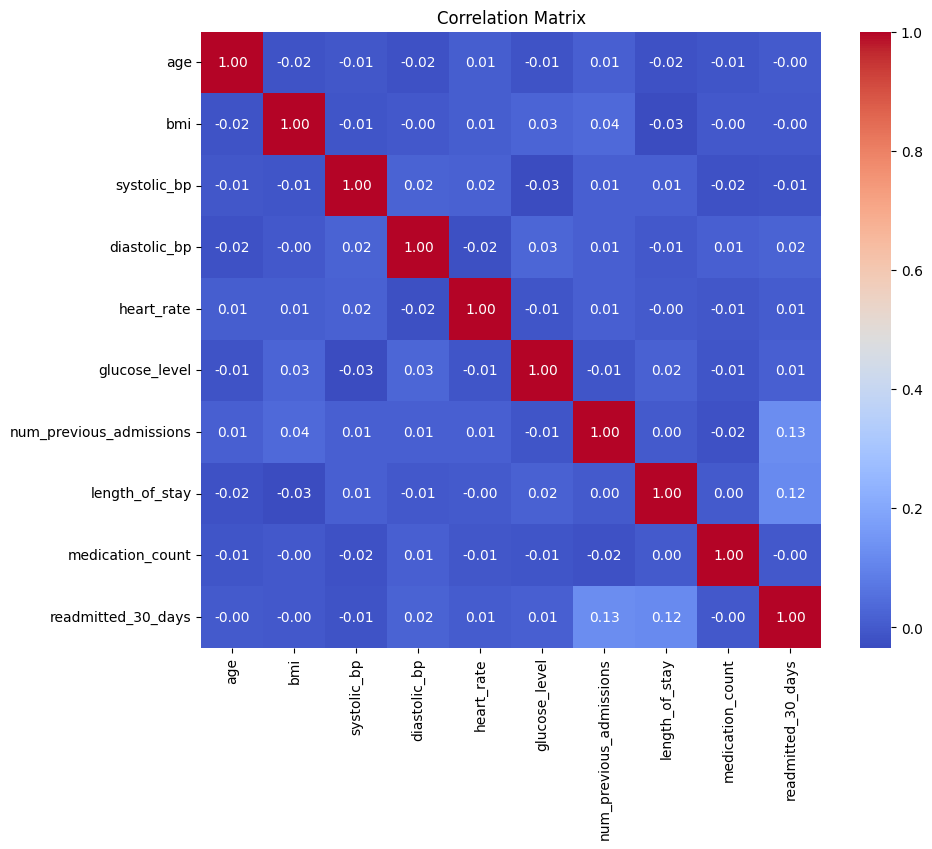

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

####Preparing Categorical and Numeric Features for ANN Modeling

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [15]:
categorical_cols = [
    'chronic_condition',
    'insurance_type',
]

In [16]:
numeric_cols = [
    'age',
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'heart_rate',
    'glucose_level',
    'num_previous_admissions',
    'length_of_stay',
    'medication_count',
]

In [17]:
binary_cols = [
    'smoker',
    'followup_appointment'
]


### Additional EDA visualizations

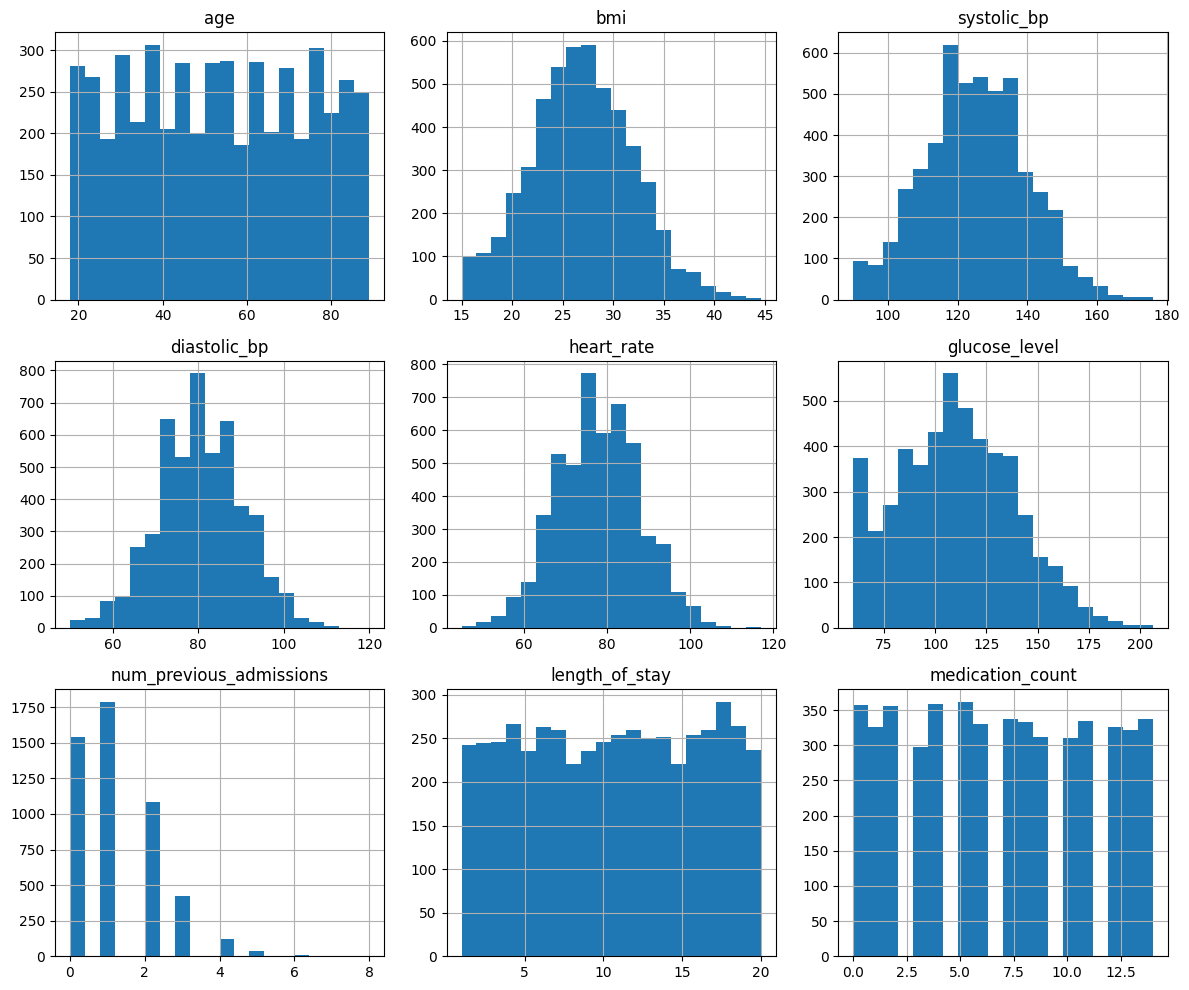

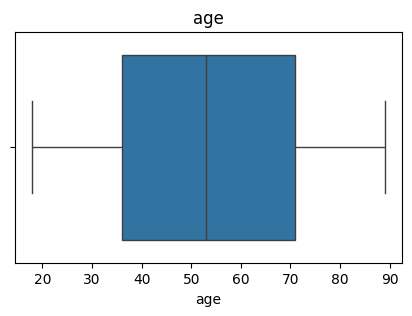

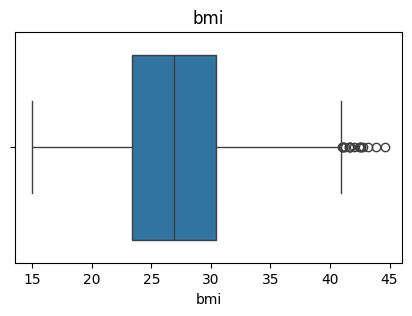

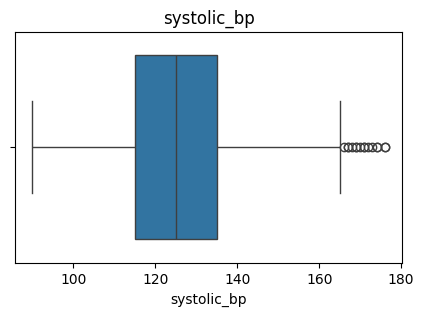

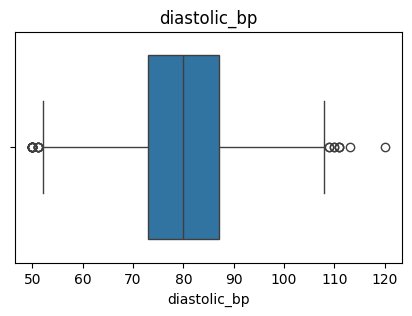

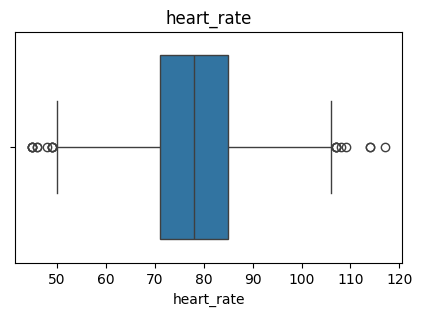

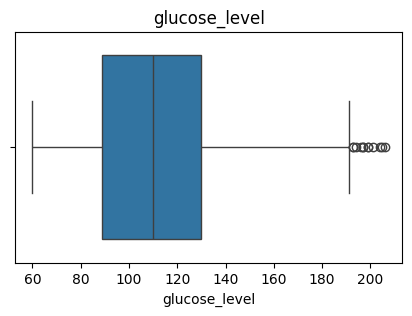

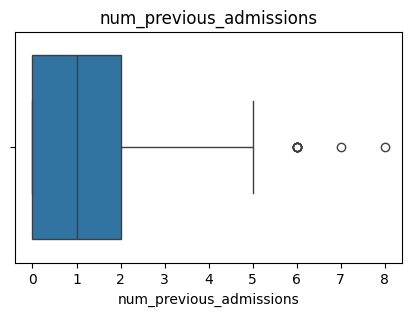

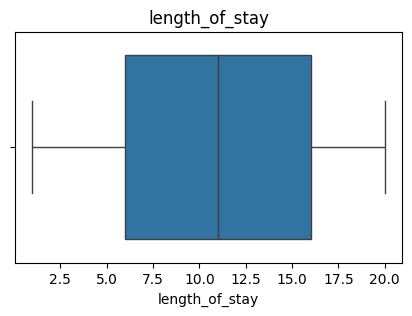

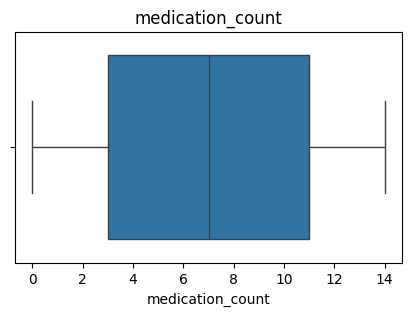

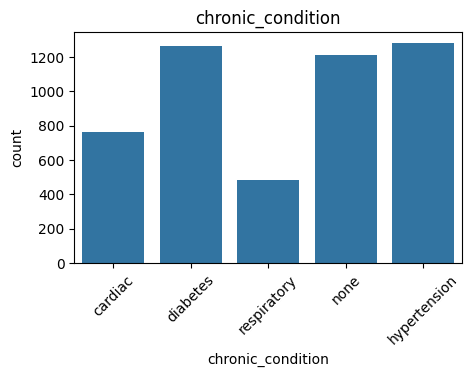

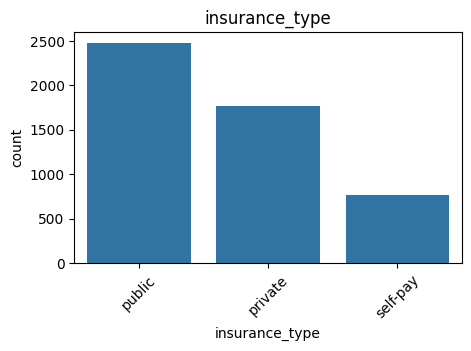

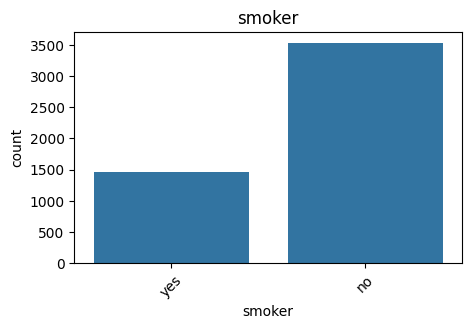

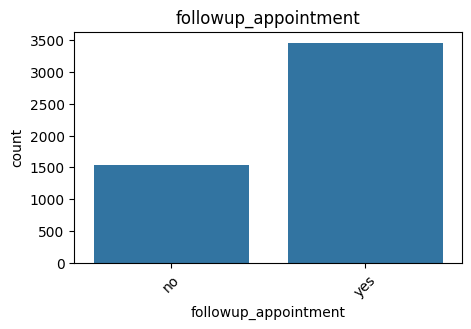

In [18]:
# Distribution of numerical features
df[numeric_cols].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots for outlier detection
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Distribution of categorical variables
for col in categorical_cols + binary_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [19]:
target_col = 'readmitted_30_days'


In [20]:
# Create the preprocessing transformer:
# One-hot encode categorical variables
# Scale numeric features

In [21]:
# binary variable to 0 - 1
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df['followup_appointment'] = df['followup_appointment'].map({'no': 0, 'yes': 1})

In [22]:
df['smoker'].unique()

array([1, 0])

In [23]:
df['followup_appointment'].unique()

array([0, 1])

In [24]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough' #keep smoker, followup_appointment, target
)

In [25]:
# separate features and target
X = df[categorical_cols + numeric_cols + binary_cols]
y = df[target_col]


In [26]:
X_processed = preprocessor.fit_transform(X)

In [27]:
X_processed.shape

(5000, 19)

### interpretation of Encoded and Scaled Feature Matrix

the transformed feature matrix contains 19 columns, which is expected because the one-hot encoding of categorical fields expands each category into a separate binary feature.

**Splitting the Dataset into Training and Testing Sets**

In [28]:
# perform an 80-20 stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2,random_state = 42, stratify = y)
# Display the shapes of the resulting sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 19), (1000, 19), (4000,), (1000,))

#### **Interpretation of the Training and Testing Split**
The dataset has been divided into training and testing subsets using an 80-20 ratio while preserving the class distribution through stratified sampling. The training set contains 4000 records, and test set contains 1000 records.

### Distribution of Readmitted vs Non-Readmitted Patients within 30 days of discharge.

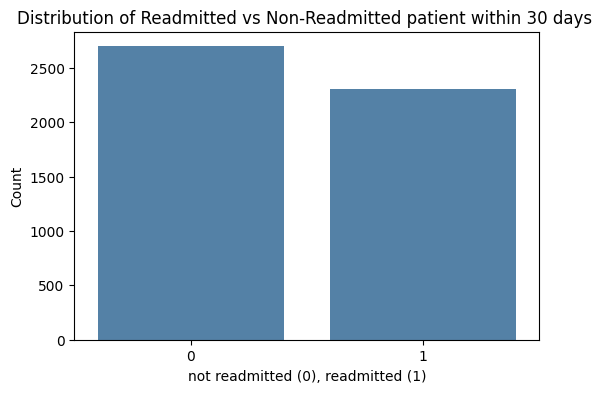

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='readmitted_30_days', color='steelblue')

plt.title('Distribution of Readmitted vs Non-Readmitted patient within 30 days ')
plt.xlabel('not readmitted (0), readmitted (1)')
plt.ylabel('Count')
plt.show()

## **Forward Propagation and Loss Intuition**

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization

In [31]:
# activation function
def relu(x):
  return np.maximum(0,x)

In [32]:
def sigmoid(x):
  out=1/(1+np.exp(-x))
  return out

In [33]:
def tanh(x):
    return np.tanh(x)

In [34]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

In [35]:
# Select the first 3 samples from the training set
X_sample = X_train[:50]
X_sample.shape

(50, 19)

In [36]:
# Random initialisation of weights and bias
# Compute z = XW + b and apply activation


In [37]:
np.random.seed(42)
W = np.random.randn(X_sample.shape[1])
b = np.random.randn(1)[0]
print(W,b)

[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004 -0.46341769 -0.46572975
  0.24196227 -1.91328024 -1.72491783 -0.56228753 -1.01283112  0.31424733
 -0.90802408] -1.4123037013352915


In [38]:
W.shape

(19,)

In [39]:
X_sample.shape

(50, 19)

In [40]:
z = np.dot(X_sample, W) + b

In [41]:
z.shape

(50,)

In [42]:
y_pred = relu(z)

In [43]:
y_pred

array([0.        , 2.18468583, 0.        , 0.        , 2.5375892 ,
       0.        , 3.3741927 , 3.01034304, 3.58787483, 0.65924833,
       0.76515465, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 5.36024069, 0.        , 0.        ,
       0.        , 0.        , 2.14499918, 0.        , 0.        ,
       4.59040049, 3.30151657, 0.        , 0.        , 8.14079818,
       0.67969665, 3.63436139, 0.        , 0.93201371, 0.        ,
       0.        , 3.05017417, 3.1527823 , 0.        , 0.        ,
       5.57249218, 0.        , 0.        , 3.22916786, 0.        ,
       0.        , 0.        , 1.28882732, 0.        , 0.        ])

In [44]:
# Random weights and bias for output layer
W2 = np.random.randn()
b2 = np.random.randn()

In [45]:
# Output layer
z2 = y_pred * W2 + b2

In [46]:
# Final Prediction
y_pred_prob = sigmoid(z2)


In [47]:
print('Output layer prediction:')
print(y_pred_prob)

Output layer prediction:
[0.44379448 0.95148753 0.44379448 0.44379448 0.97050049 0.44379448
 0.99116014 0.98502565 0.99352164 0.6770943  0.71005922 0.44379448
 0.44379448 0.44379448 0.44379448 0.44379448 0.44379448 0.9995148
 0.44379448 0.44379448 0.44379448 0.44379448 0.948731   0.44379448
 0.44379448 0.99850202 0.99017632 0.44379448 0.44379448 0.99999175
 0.6836118  0.99394574 0.44379448 0.75772158 0.44379448 0.44379448
 0.9858628  0.98781266 0.44379448 0.44379448 0.99964447 0.44379448
 0.44379448 0.9890894  0.44379448 0.44379448 0.44379448 0.84066601
 0.44379448 0.44379448]


### Interpretation forward propagation
50 training samples were selected to demonstrate forward propagation. Random weights and a bias were initialized, and the linear combination z=XW+b was computed. The ReLU activation function was then applied to produce the hidden layer outputs. ReLU replaces all negative values with zero while retaining positive values, allowing the neural network to learn non-linear relationships in the data.

In [48]:
#Compare MSE and Binary Cross-Entropy
y_true = y_train.iloc[:50].values

In [49]:
# Mean Squared Error (MSE)
mse = np.mean((y_true - y_pred_prob) ** 2)

print("Mean Squared Error:", mse)


Mean Squared Error: 0.4040499970556351


In [50]:
# Binary Cross-Entropy (BCE)
epsilon = 1e-15
y_pred_prob = np.clip(y_pred_prob, epsilon, 1-epsilon)

bce = -np.mean(
    y_true * np.log(y_pred_prob) +
    (1-y_true) * np.log(1-y_pred_prob)
)

print("Binary Cross-Entropy:", bce)



Binary Cross-Entropy: 1.7520762219039347


The Mean Squared Error (MSE) value is 0.4040, indicating the average squared difference between the predicted and actual values. The Binary Cross-Entropy (BCE) value is 1.7521, which measures the error in the predicted probabilities for binary classification.

## **Build Baseline ANN in TensorFlow/Keras**

In [51]:
# 10 jun wala doubt session
# cicago case 13 jun
# 17 jun for third point

In [52]:
input_dim = X_train.shape[1]
print(input_dim)

19


In [53]:
model = Sequential()
model.add(Input(shape=(input_dim,))) #Input Layer

model.add(Dense(50, activation="relu")) #Hidden Layer

model.add(Dense(30, activation="relu")) #Hidden Layer

model.add(Dense(1, activation="sigmoid")) #Output Layer

In [54]:

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [55]:
# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5703 - loss: 0.6772 - val_accuracy: 0.6225 - val_loss: 0.6564
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6381 - loss: 0.6388 - val_accuracy: 0.6650 - val_loss: 0.6251
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6522 - loss: 0.6193 - val_accuracy: 0.6587 - val_loss: 0.6223
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6553 - loss: 0.6093 - val_accuracy: 0.6637 - val_loss: 0.6070
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6675 - loss: 0.6029 - val_accuracy: 0.6675 - val_loss: 0.6036
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6706 - loss: 0.5989 - val_accuracy: 0.6525 - val_loss: 0.6049
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6744 - loss: 0.5947 - val_accuracy: 0.6600 - val_loss: 0.6054
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6847 - loss: 0.5891 - val_accuracy: 0.

In [57]:
model.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6100 - loss: 0.6791  


[0.6790774464607239, 0.6100000143051147]

The ANN consists of an input layer, two hidden layers, and an output layer. The first hidden layer contains 50 neurons, while the second hidden layer contains 30 neurons, both using the ReLU activation function to learn complex patterns from the input features. The output layer contains one neuron with a sigmoid activation function, which predicts the probability of a patient being readmitted within 30 days. The model is trained using the Adam optimizer and binary cross-entropy loss, making it suitable for binary classification.

## **Hyperparameter Tuning & Regularization**


* **Experiment: Changing the Learning Rate**

In [58]:
model_lr = Sequential()
model_lr.add(Input(shape=(input_dim,))) #Input Layer
model_lr.add(Dense(50, activation="relu")) #Hidden Layer
model_lr.add(Dense(30, activation="relu")) #Hidden Layer
model_lr.add(Dense(1, activation="sigmoid")) #Output Layer

In [59]:
from tensorflow.keras.optimizers import Adam
model_lr.compile(
    optimizer=Adam(learning_rate=0.01),   # Changed learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [60]:
model_lr.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6234 - loss: 0.6520 - val_accuracy: 0.6363 - val_loss: 0.6229
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6547 - loss: 0.6202 - val_accuracy: 0.6475 - val_loss: 0.6103
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6637 - loss: 0.6086 - val_accuracy: 0.6700 - val_loss: 0.6114
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6716 - loss: 0.6017 - val_accuracy: 0.6587 - val_loss: 0.6105
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6750 - loss: 0.5923 - val_accuracy: 0.6438 - val_loss: 0.6167
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6806 - loss: 0.5947 - val_accuracy: 0.6662 - val_loss: 0.6157
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6916 - loss: 0.5801 - val_accuracy: 0.6500 - val_loss: 0.6188
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6997 - loss: 0.5710 - val_accuracy: 0.

In [61]:
model_lr.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6000 - loss: 1.0077  


[1.0076526403427124, 0.6000000238418579]

* **Experiment: Changing the Batch Size**

In [62]:
model_batch = Sequential()
model_batch.add(Input(shape=(input_dim,))) #Input Layer
model_batch.add(Dense(50, activation="relu")) #Hidden Layer
model_batch.add(Dense(30, activation="relu")) #Hidden Layer
model_batch.add(Dense(1, activation="sigmoid")) #Output Layer

In [63]:
model_batch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [64]:
model_batch.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=64)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5650 - loss: 0.6763 - val_accuracy: 0.6162 - val_loss: 0.6515
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6372 - loss: 0.6433 - val_accuracy: 0.6463 - val_loss: 0.6309
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6503 - loss: 0.6246 - val_accuracy: 0.6625 - val_loss: 0.6176
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6538 - loss: 0.6139 - val_accuracy: 0.6662 - val_loss: 0.6095
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6587 - loss: 0.6087 - val_accuracy: 0.6687 - val_loss: 0.6072
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6697 - loss: 0.6044 - val_accuracy: 0.6687 - val_loss: 0.6075
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6759 - loss: 0.6011 - val_accuracy: 0.6762 - val_loss: 0.6060
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6753 - loss: 0.5981 - val_accuracy: 0.6662 - val_loss:

In [65]:
model_batch.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6280 - loss: 0.6607


[0.6606636643409729, 0.628000020980835]

* **Experiment: Changing Epoch**

In [66]:
model_epoch = Sequential()
model_epoch.add(Input(shape=(input_dim,))) #Input Layer
model_epoch.add(Dense(50, activation="relu")) #Hidden Layer
model_epoch.add(Dense(30, activation="relu")) #Hidden Layer
model_epoch.add(Dense(1, activation="sigmoid")) #Output Layer

In [67]:
model_epoch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
model_epoch.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5856 - loss: 0.6689 - val_accuracy: 0.6450 - val_loss: 0.6387
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6459 - loss: 0.6322 - val_accuracy: 0.6538 - val_loss: 0.6226
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6466 - loss: 0.6172 - val_accuracy: 0.6587 - val_loss: 0.6125
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6562 - loss: 0.6103 - val_accuracy: 0.6675 - val_loss: 0.6084
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6612 - loss: 0.6053 - val_accuracy: 0.6550 - val_loss: 0.6078
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6647 - loss: 0.6014 - val_accuracy: 0.6575 - val_loss: 0.6108
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6697 - loss: 0.5965 - val_accuracy: 0.6650 - val_loss: 0.6117
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6716 - loss: 0.5948 - val_accuracy: 0.

In [69]:
model_epoch.evaluate(X_test, y_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6030 - loss: 0.7711  


[0.771122932434082, 0.6029999852180481]

* **Experiment: Changing Dropout**





In [70]:
model_dropout = Sequential()
model_dropout.add(Input(shape=(input_dim,))) #Input Layer

model_dropout.add(Dense(50, activation="relu")) #Hidden Layer
model_dropout.add(Dropout(0.3))

model_dropout.add(Dense(30, activation="relu")) #Hidden Layer
model_dropout.add(Dropout(0.3))

model_dropout.add(Dense(1, activation="sigmoid")) #Output Layer

In [71]:
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [72]:
model_dropout.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5281 - loss: 0.7000 - val_accuracy: 0.6187 - val_loss: 0.6607
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5678 - loss: 0.6739 - val_accuracy: 0.6288 - val_loss: 0.6455
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5947 - loss: 0.6601 - val_accuracy: 0.6425 - val_loss: 0.6317
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6197 - loss: 0.6486 - val_accuracy: 0.6513 - val_loss: 0.6229
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6344 - loss: 0.6379 - val_accuracy: 0.6450 - val_loss: 0.6192
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6500 - loss: 0.6291 - val_accuracy: 0.6625 - val_loss: 0.6117
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6356 - loss: 0.6284 - val_accuracy: 0.6637 - val_loss: 0.6109
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6491 - loss: 0.6249 - val_accuracy: 0.

In [73]:
model_dropout.evaluate(X_test, y_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6310 - loss: 0.6431  


[0.6430976986885071, 0.6309999823570251]

* **Experiment with activation function using sigmoid**

In [74]:
model_adam_sigmoid = Sequential()
model_adam_sigmoid.add(Input(shape=(input_dim,))) #Input Layer

model_adam_sigmoid.add(Dense(50, activation="sigmoid")) #Hidden Layer

model_adam_sigmoid.add(Dense(30, activation="sigmoid")) #Hidden Layer

model_adam_sigmoid.add(Dense(1, activation="sigmoid")) #Output Layer

In [75]:
model_adam_sigmoid.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [76]:
model_adam_sigmoid.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5406 - loss: 0.7099 - val_accuracy: 0.5663 - val_loss: 0.6810
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5694 - loss: 0.6791 - val_accuracy: 0.6037 - val_loss: 0.6703
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6094 - loss: 0.6660 - val_accuracy: 0.5825 - val_loss: 0.6564
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6309 - loss: 0.6518 - val_accuracy: 0.6450 - val_loss: 0.6441
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6434 - loss: 0.6382 - val_accuracy: 0.6587 - val_loss: 0.6280
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6484 - loss: 0.6271 - val_accuracy: 0.6538 - val_loss: 0.6168
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6516 - loss: 0.6217 - val_accuracy: 0.6425 - val_loss: 0.6157
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6497 - loss: 0.6189 - val_accuracy: 0.

In [77]:
model_adam_sigmoid.evaluate(X_test, y_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6440 - loss: 0.6346  


[0.6345614790916443, 0.6439999938011169]

* **Experiment with activation function using tanh**

In [78]:
model_adam_t = Sequential()
model_adam_t.add(Input(shape=(input_dim,))) #Input Layer

model_adam_t.add(Dense(50, activation="tanh")) #Hidden Layer

model_adam_t.add(Dense(30, activation="tanh")) #Hidden Layer

model_adam_t.add(Dense(1, activation="sigmoid")) #Output Layer

In [79]:
model_adam_t.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
model_adam_t.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6237 - loss: 0.6445 - val_accuracy: 0.6675 - val_loss: 0.6090
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6463 - loss: 0.6220 - val_accuracy: 0.6700 - val_loss: 0.6024
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6506 - loss: 0.6180 - val_accuracy: 0.6762 - val_loss: 0.6010
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6541 - loss: 0.6156 - val_accuracy: 0.6625 - val_loss: 0.6027
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6500 - loss: 0.6162 - val_accuracy: 0.6450 - val_loss: 0.6108
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6572 - loss: 0.6126 - val_accuracy: 0.6587 - val_loss: 0.6022
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6559 - loss: 0.6107 - val_accuracy: 0.6662 - val_loss: 0.6058
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6578 - loss: 0.6085 - val_accuracy: 0.

In [81]:
model_adam_t.evaluate(X_test, y_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6360 - loss: 0.6498  


[0.6497852206230164, 0.6359999775886536]

**Interpretation of Hyperparameter Tuning & Regularization**
* Learning Rate: Changing the learning rate affected the model's convergence speed and training stability. An appropriate learning rate helped the model learn efficiently, while a higher learning rate could lead to unstable training.
* Batch Size: Increasing the batch size changed the frequency of weight updates. Larger batch sizes generally trained faster but could slightly affect the model's ability to generalize.
* Epochs: Increasing the number of epochs allowed the model to learn for a longer time, which could improve accuracy but also increase the risk of overfitting if training continued for too long.
* Dropout: Adding dropout (0.3) reduced overfitting by randomly disabling neurons during training, helping the model generalize better on unseen data.
* Activation Function (Sigmoid): Replacing ReLU with sigmoid in the hidden layers generally resulted in slower learning and lower performance due to the vanishing gradient problem, making ReLU the
better choice for this model.

* Activation Function (Tanh): Replacing the ReLU activation function with tanh resulted in a test accuracy of 62.5%, indicating lower performance than the baseline. This suggests that ReLU is more effective than tanh for the hidden layers in this binary classification task.

## **Advanced Training Strategies & Report in markdown**

In [82]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [83]:
model = Sequential()
model.add(Input(shape=(input_dim,)))  # Input Layer
model.add(Dense(50, activation="relu"))  # Hidden Layer 1
model.add(BatchNormalization())          # Batch Normalization

model.add(Dense(30, activation="relu"))  # Hidden Layer 2
model.add(BatchNormalization())          # Batch Normalization

model.add(Dense(1, activation="sigmoid"))  # Output Layer

In [84]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [85]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [86]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [87]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 50)             │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,721 (10.63 KB)

 Non-trainable params: 160 (640.00 B)

In [88]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5541 - loss: 0.7419 - val_accuracy: 0.6012 - val_loss: 0.6606 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.6504 - val_accuracy: 0.6200 - val_loss: 0.6402 - learning_rate: 0.0010
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6403 - loss: 0.6309 - val_accuracy: 0.6350 - val_loss: 0.6281 - learning_rate: 0.0010
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6500 - loss: 0.6187 - val_accuracy: 0.6300 - val_loss: 0.6280 - learning_rate: 0.0010
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6600 - loss: 0.6126 - val_accuracy: 0.6375 - val_loss: 0.6295 - learning_rate: 0.0010
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6700 - loss: 0.5994 - val_accuracy: 0.6375 - val_loss: 0.6305 - learning_rate: 0.0010
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6803 - loss: 0.5892 - 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


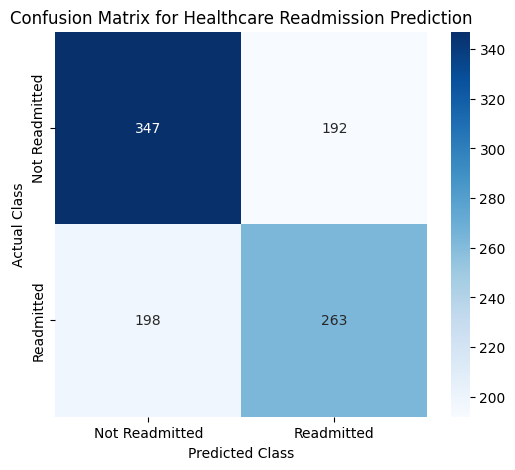

Classification Report
                precision    recall  f1-score   support

Not Readmitted       0.64      0.64      0.64       539
    Readmitted       0.58      0.57      0.57       461

      accuracy                           0.61      1000
     macro avg       0.61      0.61      0.61      1000
  weighted avg       0.61      0.61      0.61      1000



In [89]:
# Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report
# Predict readmission probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities into class labels (0 = Not Readmitted, 1 = Readmitted)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted']
)

plt.title('Confusion Matrix for Healthcare Readmission Prediction')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Display Classification Report
print("Classification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Readmitted', 'Readmitted']
))


### Practical Recommendations for Hospital Readmission Management
Based on the ANN model, hospitals can:
* Identify high-risk patients before discharge.
* Schedule follow-up appointments for patients with elevated readmission risk.
* Monitor patients with chronic conditions more closely.
* Allocate healthcare resources more efficiently.
* Improve discharge planning and patient education.
* Reduce avoidable hospital readmissions and associated healthcare costs.

## **Conclusion**
This project demonstrated the successful application of Artificial Neural Networks for predicting 30-day hospital readmissions. Data preprocessing, feature encoding, and normalization prepared the dataset for deep learning. Hyperparameter tuning and advanced training techniques—including Batch Normalization, Early Stopping, and Learning Rate Scheduling—improved model performance and reduced overfitting. The final ANN model provides a practical decision-support tool that can assist healthcare providers in identifying patients at high risk of readmission and implementing timely interventions.